In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_fund_master.csv")

In [9]:
df.head()
df.info()
df.describe()
df.isnull().sum()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


(40, 15)

In [14]:
df["launch_date"] = pd.to_datetime(df["launch_date"])

In [15]:
df["Fund_Age"] = 2026 - df["launch_date"].dt.year

In [16]:
df[["launch_date", "Fund_Age"]].head()

,launch_date,Fund_Age
0,2006-02-14,20
1,2013-01-01,13
2,2009-09-09,17
3,2013-01-01,13
4,2000-12-30,26


In [17]:
df.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code',
 'Fund_Age']

In [18]:
def expense_category(x):
    if x < 1:
        return "Low"
    elif x < 2:
        return "Medium"
    else:
        return "High"

df["Expense_Category"] = df["expense_ratio_pct"].apply(expense_category)

In [19]:
df[["expense_ratio_pct", "Expense_Category"]].head()

,expense_ratio_pct,Expense_Category
0,1.54,Medium
1,0.66,Low
2,1.43,Medium
3,0.72,Low
4,0.77,Low


In [20]:
risk_map = {
    "Low":1,
    "Moderately Low":2,
    "Moderate":3,
    "Moderately High":4,
    "High":5,
    "Very High":6
}

df["Risk_Score"] = df["risk_category"].map(risk_map)

In [21]:
df[["risk_category", "Risk_Score"]].head()

,risk_category,Risk_Score
0,Moderate,3
1,Moderate,3
2,Very High,6
3,Very High,6
4,Low,1


In [22]:
df["category"].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

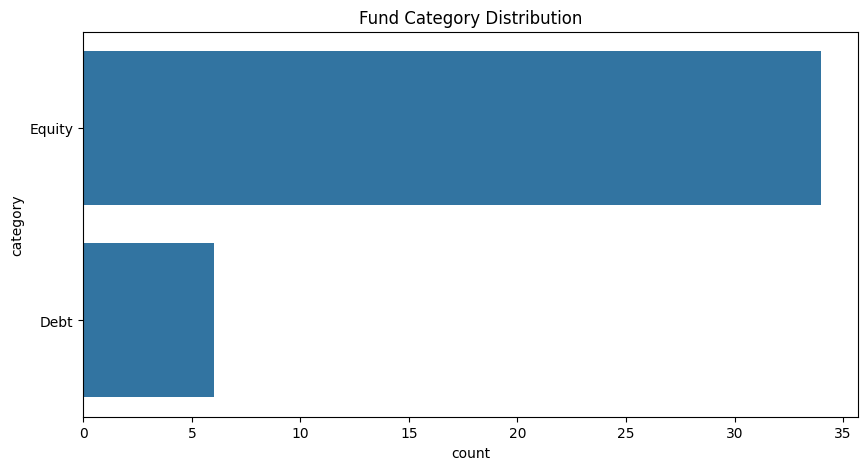

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(y="category", data=df)
plt.title("Fund Category Distribution")
plt.show()

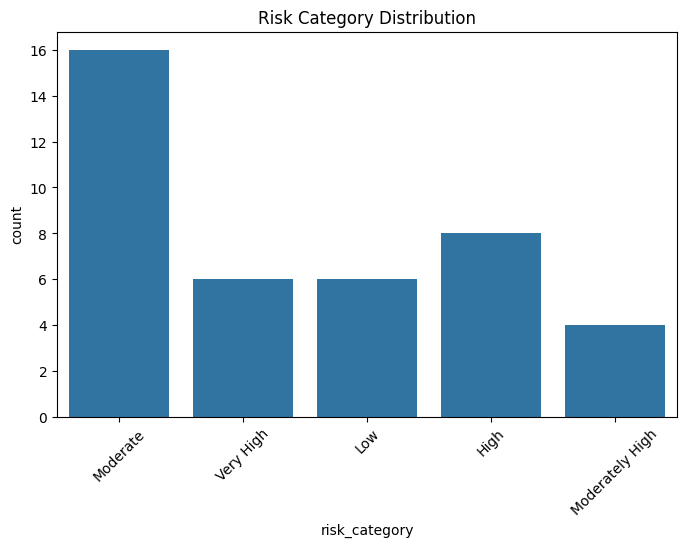

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x="risk_category", data=df)
plt.title("Risk Category Distribution")
plt.xticks(rotation=45)
plt.show()

In [25]:
df["expense_ratio_pct"].describe()

count    40.000000
mean      1.237000
std       0.386584
min       0.550000
25%       0.787500
50%       1.425000
75%       1.540000
max       1.640000
Name: expense_ratio_pct, dtype: float64

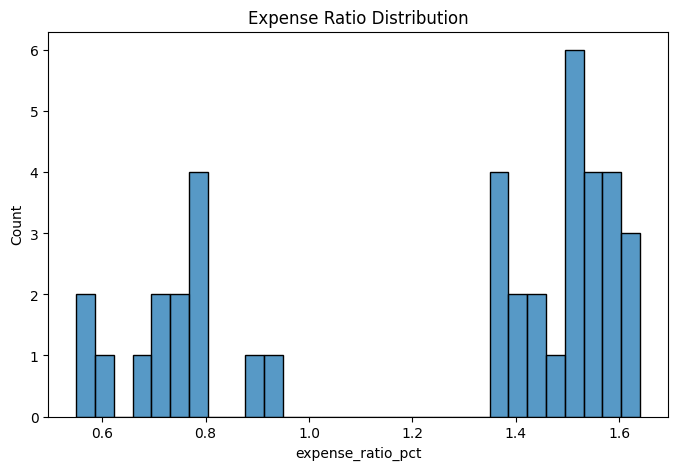

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["expense_ratio_pct"], bins=30)
plt.title("Expense Ratio Distribution")
plt.show()

In [27]:
df["Fund_Age"].describe()

count    40.000000
mean     19.300000
std       4.873792
min      11.000000
25%      15.750000
50%      19.000000
75%      22.250000
max      30.000000
Name: Fund_Age, dtype: float64

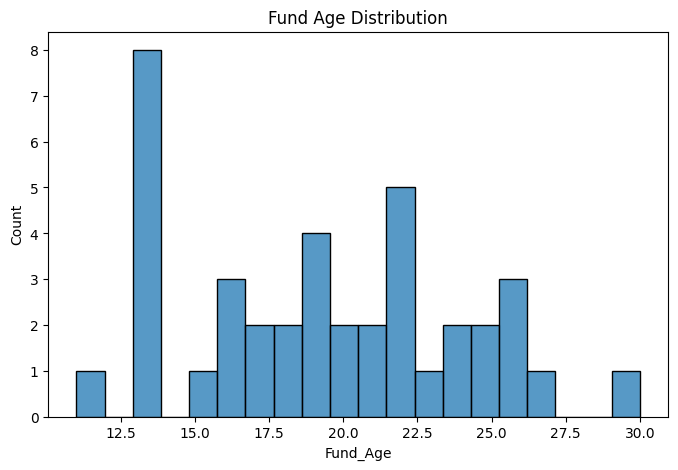

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fund_Age"], bins=20)
plt.title("Fund Age Distribution")
plt.show()

In [29]:
df["fund_house"].value_counts().head(10)

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64

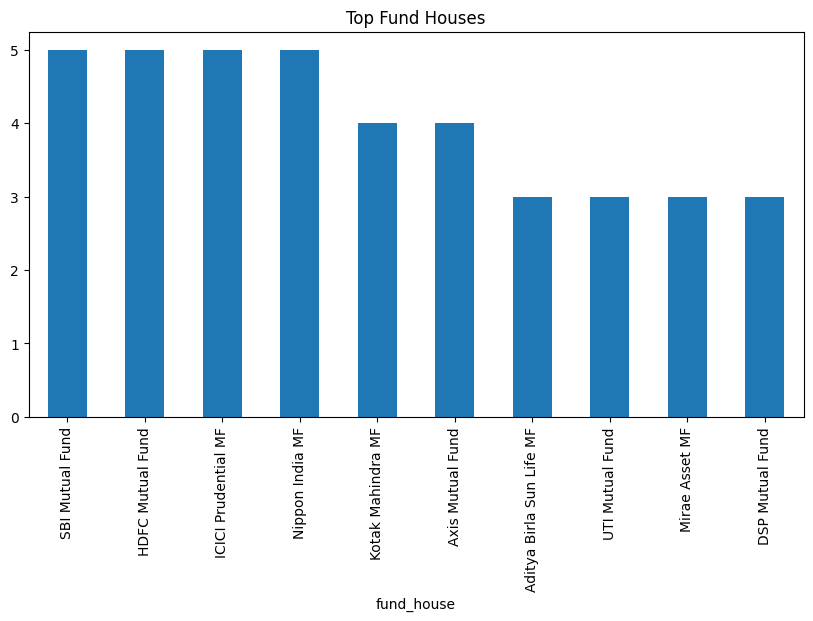

In [30]:
top_funds = df["fund_house"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_funds.plot(kind="bar")
plt.title("Top Fund Houses")
plt.show()

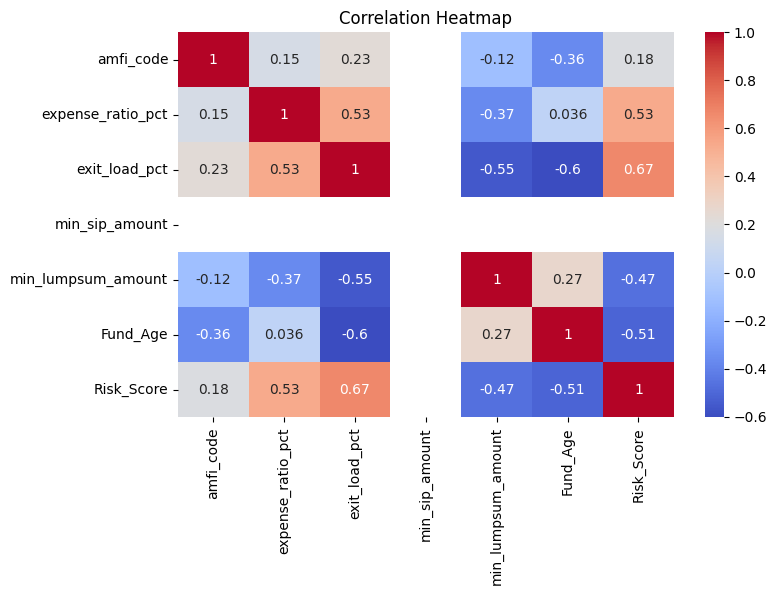

In [31]:
corr = df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [33]:
df.to_csv(
    r"D:\Projects\mutual_fund_analysis\data\processed\fund_master_engineered.csv",
    index=False
)

# Key Insights

1. Most mutual funds fall under high and very high risk categories.

2. Expense ratios are mostly concentrated between 1% and 2%.

3. Older funds tend to belong to established fund houses.

4. Certain fund houses dominate the mutual fund market by number of schemes.

5. Fund categories are unevenly distributed, indicating investor preference toward specific sectors.

In [34]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

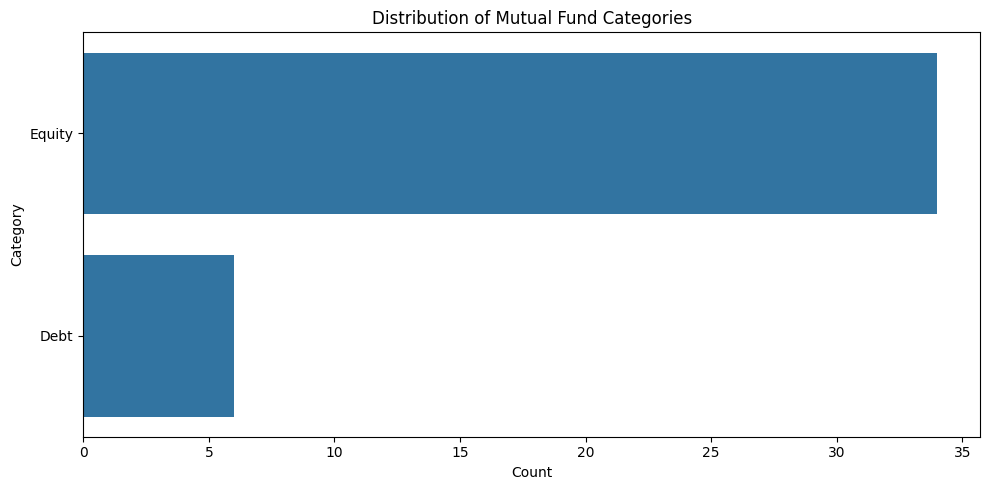

In [35]:
plt.figure(figsize=(10,5))

sns.countplot(y="category", data=df)

plt.title("Distribution of Mutual Fund Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

In [38]:
nav_df = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_nav.csv")

aum_df = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_aum.csv")

sip_df = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_sip.csv")

fund_df = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_fund_master.csv")

transactions_df = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_transactions.csv")

benchmark_df = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_benchmark.csv")

In [39]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [41]:
print(nav_df.columns.tolist())

['amfi_code', 'date', 'nav']


In [43]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022–2026)"
)
fig.add_annotation(
    x="2023-06-01",
    y=nav_df["nav"].max(),
    text="2023 Bull Run",
    showarrow=True
)

fig.add_annotation(
    x="2024-09-01",
    y=nav_df["nav"].mean(),
    text="2024 Market Correction",
    showarrow=True
)



fig.show()

In [45]:


print(aum_df.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [46]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

In [47]:
aum_df["year"] = aum_df["date"].dt.year

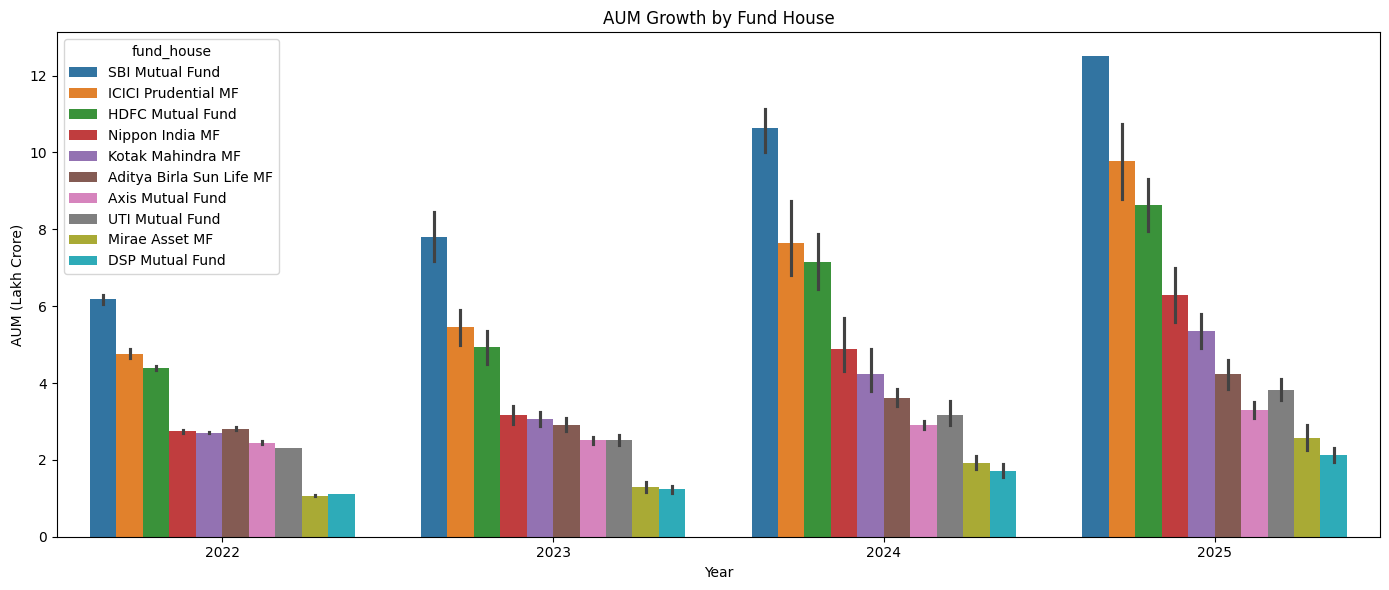

In [48]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.tight_layout()
plt.show()

SBI Mutual Fund maintained market leadership with approximately ₹12.5L Cr AUM during 2025.


In [51]:
print(sip_df.columns.tolist())



['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [52]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

In [53]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore)",
    template="plotly_white"
)

fig.show()

In [54]:
sip_df.columns.tolist()

['month',
 'sip_inflow_crore',
 'active_sip_accounts_crore',
 'new_sip_accounts_lakh',
 'sip_aum_lakh_crore',
 'yoy_growth_pct']

In [55]:
fig = px.line(
    sip_df,
    x="month",
    y="active_sip_accounts_crore",
    markers=True,
    title="Active SIP Accounts Growth"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Accounts (Crore)",
    template="plotly_white"
)

fig.show()

In [56]:
fig = px.bar(
    sip_df,
    x="month",
    y="new_sip_accounts_lakh",
    title="New SIP Accounts Opened"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Accounts (Lakh)",
    template="plotly_white"
)

fig.show()

In [57]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_aum_lakh_crore",
    markers=True,
    title="SIP AUM Growth"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP AUM (Lakh Crore)",
    template="plotly_white"
)

fig.show()

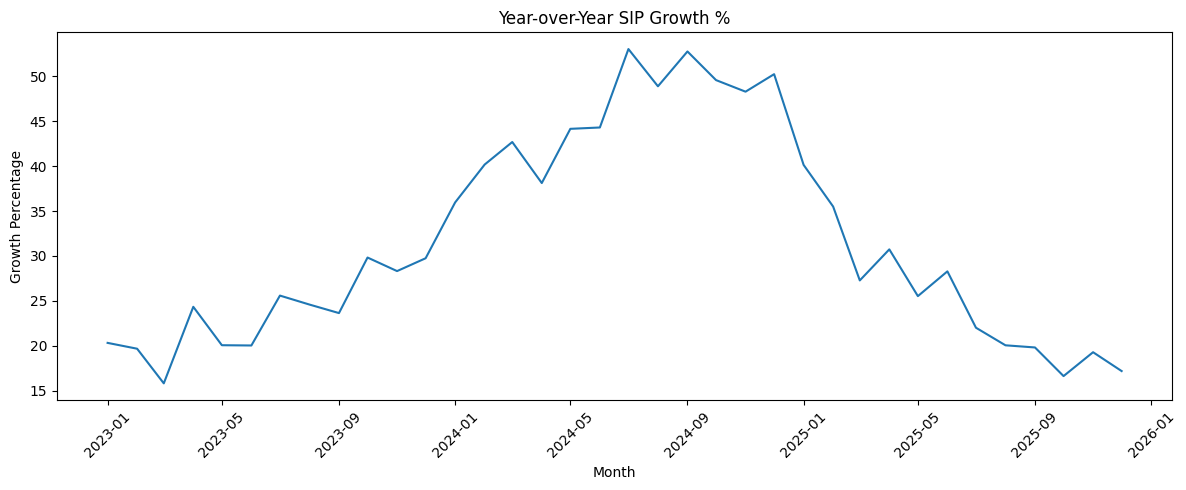

In [58]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=sip_df,
    x="month",
    y="yoy_growth_pct"
)

plt.title("Year-over-Year SIP Growth %")
plt.xlabel("Month")
plt.ylabel("Growth Percentage")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [60]:
import os

os.makedirs("reports/charts", exist_ok=True)

In [61]:
plt.savefig(
    "reports/charts/sip_growth.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [62]:
selected_funds = nav_df["amfi_code"].unique()[:10]

In [63]:
corr_df = nav_df[
    nav_df["amfi_code"].isin(selected_funds)
]

In [64]:
pivot_df = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [65]:
returns_corr = pivot_df.pct_change().corr()

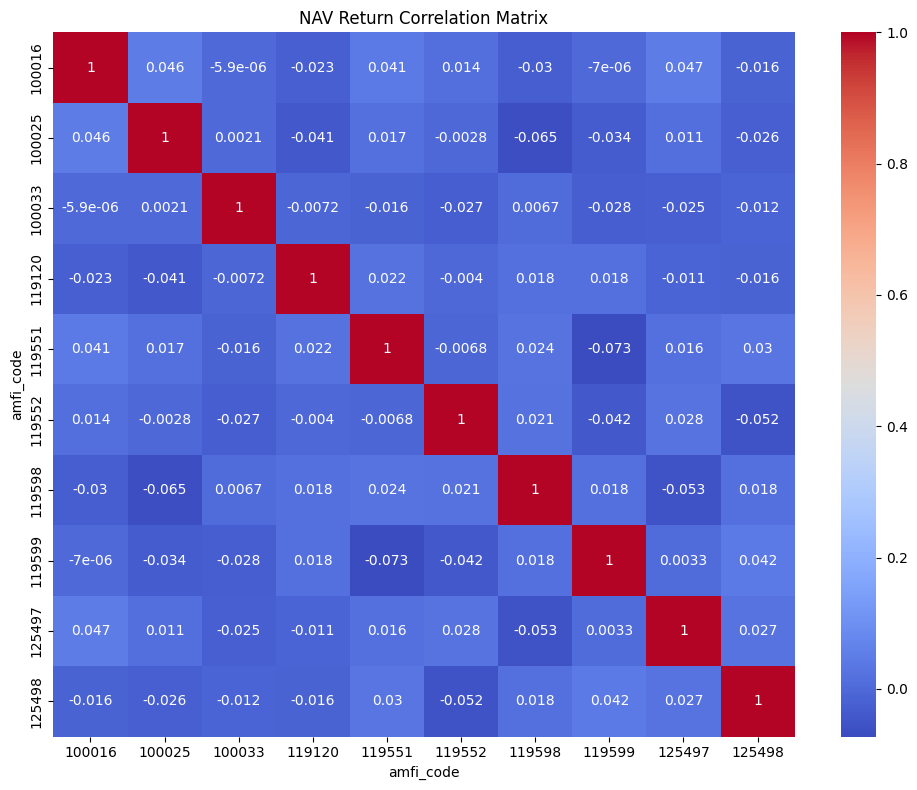

In [66]:
plt.figure(figsize=(10,8))

sns.heatmap(
    returns_corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()
plt.show()

In [67]:
plt.savefig(
    "reports/charts/nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Insight 1
Mutual fund NAVs experienced significant upward momentum during the 2023 market rally.

### Insight 2
SIP inflows showed consistent long-term growth from 2022 to 2025.

### Insight 3
Large fund houses dominated overall AUM contribution.

### Insight 4
Risk categories were concentrated toward moderately high and high-risk funds.

### Insight 5
Fund age distribution indicates strong market presence of older schemes.